In [24]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [25]:
ruta_csv = "celsius_a_fahrenheit.csv"

df_temperatura = pd.read_csv(ruta_csv)

print("Primeros 5 datos:")
print(df_temperatura.head())

print("\nInformación general:")
print(df_temperatura.info())

print("\nEstadísticas descriptivas:")
print(df_temperatura.describe())

Primeros 5 datos:
   Celsius  Fahrenheit
0      -50       -58.0
1      -40       -40.0
2      -30       -22.0
3      -20        -4.0
4      -10        14.0

Información general:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Celsius     30 non-null     int64  
 1   Fahrenheit  30 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes
None

Estadísticas descriptivas:
         Celsius  Fahrenheit
count  30.000000   30.000000
mean    2.000000   35.600000
std    22.780815   41.005466
min   -50.000000  -58.000000
25%    -6.750000   19.850000
50%     0.500000   32.900000
75%     7.750000   45.950000
max    60.000000  140.000000


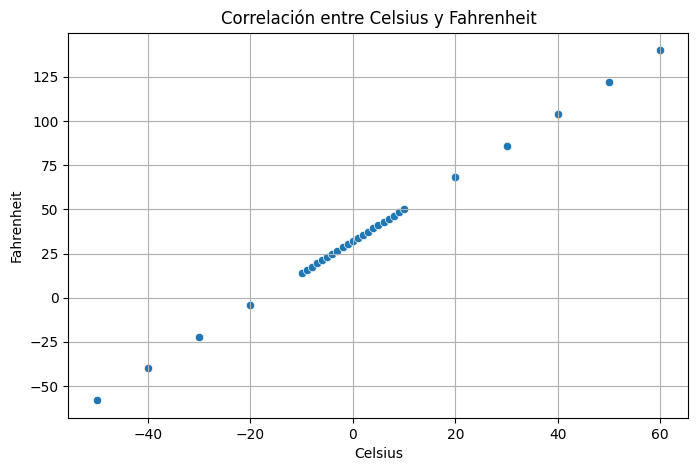

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title('Correlación entre Celsius y Fahrenheit')
plt.xlabel('Celsius')
plt.ylabel('Fahrenheit')
plt.grid(True)
plt.show()

In [27]:
X_train = df_temperatura['Celsius'].values.astype(float)
y_train = df_temperatura['Fahrenheit'].values.astype(float)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (30,)
y_train shape: (30,)


In [28]:
print("Creando modelo simple...")

modelo_simple = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])

modelo_simple.compile(
    optimizer=tf.keras.optimizers.Adam(1.0),
    loss='mean_squared_error'
)

hist_simple = modelo_simple.fit(
    X_train,
    y_train,
    epochs=300,
    verbose=False
)

print("Entrenamiento del modelo simple completado.")

Creando modelo simple...
Entrenamiento del modelo simple completado.


Llaves del historial: dict_keys(['loss'])


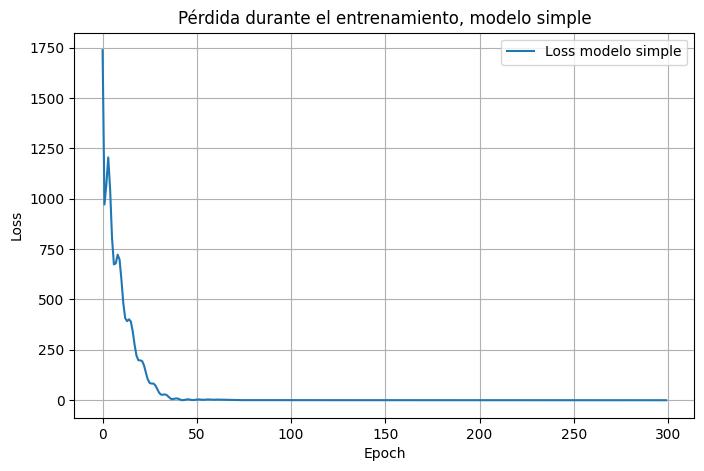

In [29]:
print("Llaves del historial:", hist_simple.history.keys())

plt.figure(figsize=(8, 5))
plt.plot(hist_simple.history['loss'], label='Loss modelo simple')
plt.title('Pérdida durante el entrenamiento, modelo simple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
temp_c = 100
temp_c_array = np.array([[temp_c]], dtype=float)

pred_simple = modelo_simple.predict(temp_c_array, verbose=0)
temp_formula = (9/5) * temp_c + 32

print(f"Temperatura en Celsius: {temp_c}")
print(f"Predicción modelo simple: {pred_simple[0][0]:.4f} °F")
print(f"Resultado fórmula exacta: {temp_formula:.4f} °F")
print(f"Error absoluto: {abs(pred_simple[0][0] - temp_formula):.4f}")

Temperatura en Celsius: 100
Predicción modelo simple: 212.0000 °F
Resultado fórmula exacta: 212.0000 °F
Error absoluto: 0.0000


In [31]:
print("Creando modelo con más capas...")

oculta1 = tf.keras.layers.Dense(units=3, input_shape=[1])
oculta2 = tf.keras.layers.Dense(units=3)
salida = tf.keras.layers.Dense(units=1)

modelo_profundo = tf.keras.Sequential([oculta1, oculta2, salida])

modelo_profundo.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

hist_profundo = modelo_profundo.fit(
    X_train,
    y_train,
    epochs=300,
    verbose=False
)

print("Entrenamiento del modelo con más capas completado.")

Creando modelo con más capas...


c:\grados-tf\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Entrenamiento del modelo con más capas completado.


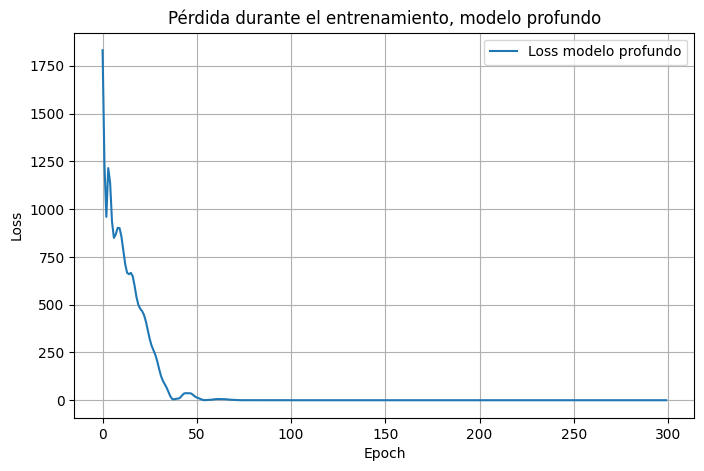

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(hist_profundo.history['loss'], label='Loss modelo profundo')
plt.title('Pérdida durante el entrenamiento, modelo profundo')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

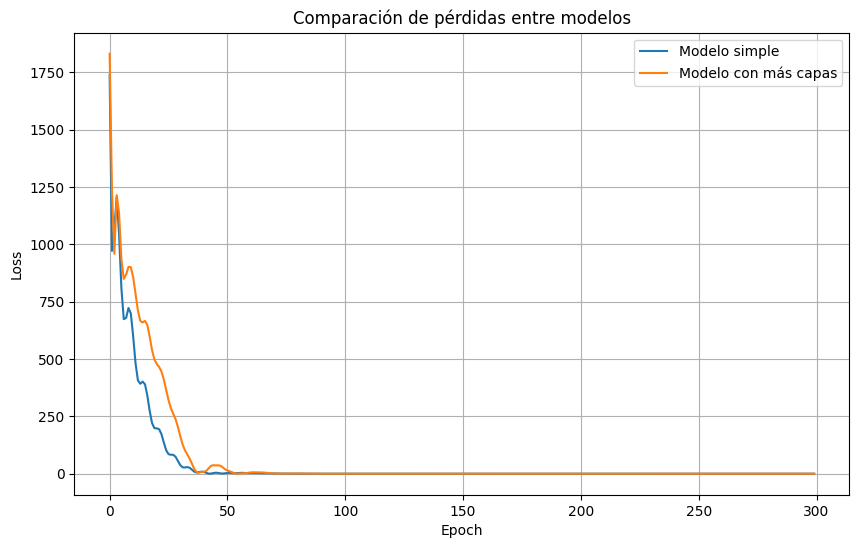

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(hist_simple.history['loss'], label='Modelo simple')
plt.plot(hist_profundo.history['loss'], label='Modelo con más capas')
plt.title('Comparación de pérdidas entre modelos')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [34]:
pred_profundo = modelo_profundo.predict(temp_c_array, verbose=0)

print(f"Temperatura en Celsius: {temp_c}")
print(f"Predicción modelo profundo: {pred_profundo[0][0]:.4f} °F")
print(f"Resultado fórmula exacta: {temp_formula:.4f} °F")
print(f"Error absoluto: {abs(pred_profundo[0][0] - temp_formula):.4f}")

Temperatura en Celsius: 100
Predicción modelo profundo: 212.0001 °F
Resultado fórmula exacta: 212.0000 °F
Error absoluto: 0.0001


In [35]:
print("Pesos de oculta1:")
print(oculta1.get_weights())

print("\nPesos de oculta2:")
print(oculta2.get_weights())

print("\nPesos de salida:")
print(salida.get_weights())

Pesos de oculta1:
[array([[-0.5564262 , -0.13472044, -0.24953184]], dtype=float32), array([-3.8348343, -0.321045 , -3.7580478], dtype=float32)]

Pesos de oculta2:
[array([[-0.9547929 , -0.9608482 ,  0.23247187],
       [-0.10810398,  0.1523711 , -0.14182873],
       [-0.7342824 , -0.8783989 , -0.34457204]], dtype=float32), array([ 3.8925853,  3.9130228, -3.483697 ], dtype=float32)]

Pesos de salida:
[array([[ 1.2519639],
       [ 1.182807 ],
       [-0.8195438]], dtype=float32), array([3.7240024], dtype=float32)]


In [36]:
loss_final_simple = hist_simple.history['loss'][-1]
loss_final_profundo = hist_profundo.history['loss'][-1]

print("RESULTADOS FINALES")
print(f"Loss final modelo simple: {loss_final_simple:.6f}")
print(f"Loss final modelo profundo: {loss_final_profundo:.6f}")

if loss_final_profundo < loss_final_simple:
    print("El modelo con más capas obtuvo una menor pérdida final.")
else:
    print("El modelo simple obtuvo una menor o igual pérdida final.")

print("\nAmbos modelos aprenden la relación entre Celsius y Fahrenheit,")
print("pero se comparan según la pérdida y la cercanía de la predicción respecto a la fórmula real.")

RESULTADOS FINALES
Loss final modelo simple: 0.000000
Loss final modelo profundo: 0.000000
El modelo simple obtuvo una menor o igual pérdida final.

Ambos modelos aprenden la relación entre Celsius y Fahrenheit,
pero se comparan según la pérdida y la cercanía de la predicción respecto a la fórmula real.


# Optimizadores: Adam, SGD y RMSProp

En este modelo se utilizó Adam porque normalmente aprende más rápido y de forma más estable. Adam ajusta automáticamente el tamaño de los cambios que hace en los pesos, por eso suele dar buenos resultados sin tener que moverle mucho. SGD es más simple, pero puede tardar más en aprender y a veces necesita más épocas o un mejor ajuste del learning rate. RMSProp también ajusta la tasa de aprendizaje y puede funcionar bien, pero en muchos casos Adam suele ser más completo. Si cambiara el optimizador, lo más probable es que cambie la velocidad de entrenamiento y la forma en que baja el error.

# Función de pérdida mean_squared_error

La función de pérdida es importante porque le dice al modelo qué tan lejos está de la respuesta correcta. En este caso se usa mean_squared_error porque el problema es de regresión, y esta función mide el error promedio al cuadrado entre el valor real y la predicción. Es útil porque castiga más los errores grandes. Otra función que se puede usar es mean_absolute_error, que mide el error absoluto. Si se usa MAE, el modelo puede comportarse un poco diferente y ser menos sensible a errores muy grandes, pero en este problema MSE suele funcionar mejor.

# Épocas suficientes para entrenar

En las modificaciones realizadas, 300 épocas fueron suficientes para que el modelo se considere entrenado. Esto se nota cuando la pérdida deja de bajar de forma importante y la gráfica se empieza a estabilizar. A partir de ese punto, seguir entrenando ya no mejora mucho el resultado.

# Importancia de las epochs
Las epochs son importantes porque indican cuántas veces el modelo recorre todos los datos de entrenamiento. Si se usan pocas, el modelo puede no aprender bien. Si se usan suficientes, el modelo ajusta mejor sus pesos y reduce el error. En pocas palabras, las epochs controlan cuánto tiempo aprende el modelo.

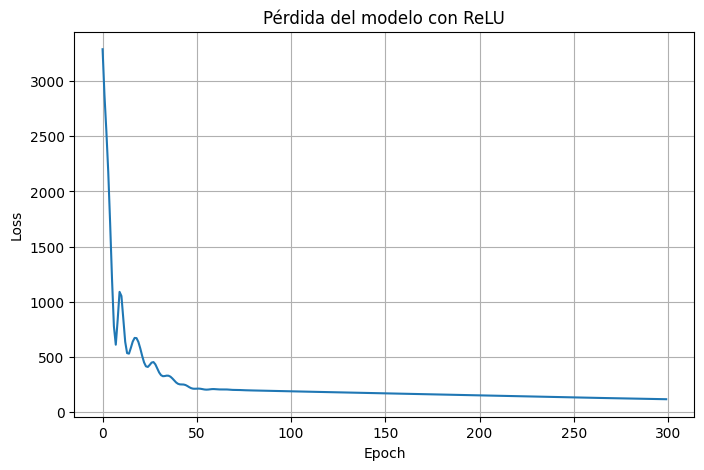

Temperatura en Celsius: 100
Predicción con ReLU: 212.1032 °F
Resultado real: 212.0000 °F
Error absoluto: 0.1032


In [37]:
# Modelo con función de activación ReLU
modelo_relu = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=3, activation='relu'),
    tf.keras.layers.Dense(units=3, activation='relu'),
    tf.keras.layers.Dense(units=1)
])

modelo_relu.compile(
    optimizer=tf.keras.optimizers.Adam(0.1),
    loss='mean_squared_error'
)

hist_relu = modelo_relu.fit(
    X_train,
    y_train,
    epochs=300,
    verbose=False
)

# Gráfica de pérdida
plt.figure(figsize=(8, 5))
plt.plot(hist_relu.history['loss'])
plt.title('Pérdida del modelo con ReLU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Predicción de prueba
temp_c = 100
temp_c_array = np.array([[temp_c]], dtype=float)

pred_relu = modelo_relu.predict(temp_c_array, verbose=0)
temp_formula = (9/5) * temp_c + 32

print(f"Temperatura en Celsius: {temp_c}")
print(f"Predicción con ReLU: {pred_relu[0][0]:.4f} °F")
print(f"Resultado real: {temp_formula:.4f} °F")
print(f"Error absoluto: {abs(pred_relu[0][0] - temp_formula):.4f}")